# Liver Disease Prediction using Machine Learning


## Problem Statement


### The objective of this project is to analyze the Indian Liver Patient Dataset (ILPD) and build multiple Machine Learning classification models to predict whether a patient is suffering from liver disease or not.


### - Perform Data Analysis (EDA)
- Clean and preprocess the dataset
- Build multiple classification models
- Compare model performance
- Select the best model
- Explain why the model makes predictions

# Step 1 : Import Required Libraries

In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Step 2 : Load Dataset

In [2]:
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv")

In [3]:
df

,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.9,1
0,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
1,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
2,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
3,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
4,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1
...,...,...,...,...,...,...,...,...,...,...,...
577,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
578,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
579,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
580,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [4]:
columns = [
    'Age',
    'Gender',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphotase',
    'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase',
    'Total_Protiens',
    'Albumin',
    'Albumin_and_Globulin_Ratio',
    'Dataset'
]

df = pd.read_csv(
    "Indian Liver Patient Dataset (ILPD).csv",
    header=None,
    names=columns
)

In [5]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


# Step 3 : Basic Information of Dataset

In [6]:
df.shape

(583, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Protiens,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Dataset,583.0,1.286449,0.452490,1.0,1.0,1.00,2.0,2.0


In [9]:
df.describe(include="object")

,Gender
count,583
unique,2
top,Male
freq,441


# Step 4 : Data Quality Assessment

## 4.1 Check Missing Values

In [10]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [11]:
missing = pd.DataFrame({
    "missing values": df.isnull().sum(),
    "percentage " : (df.isnull().sum()/len(df))*100
})
missing

,missing values,percentage
Age,0,0.000000
Gender,0,0.000000
Total_Bilirubin,0,0.000000
Direct_Bilirubin,0,0.000000
Alkaline_Phosphotase,0,0.000000
Alamine_Aminotransferase,0,0.000000
Aspartate_Aminotransferase,0,0.000000
Total_Protiens,0,0.000000
Albumin,0,0.000000
Albumin_and_Globulin_Ratio,4,0.686106


## Observation

- We will identify which columns contain missing values.
- Missing values will be handled in the data preprocessing stage.

# Step 5 : Exploratory Data Analysis (EDA)

## 5.1 Dataset Class Distribution

In [12]:
df["Dataset"].value_counts()

Dataset
1    416
2    167
Name: count, dtype: int64

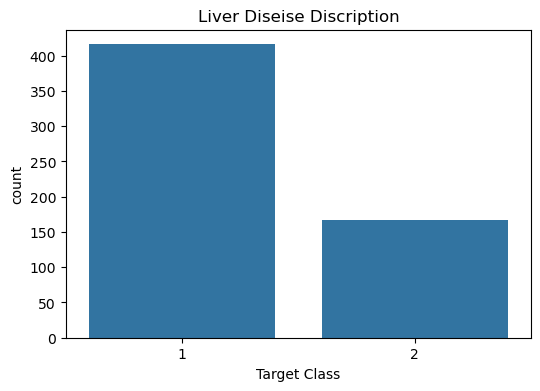

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x = "Dataset")

plt.title("Liver Diseise Discription")

plt.xlabel("Target Class")

plt.ylabel("count")

plt.show()

### 
- This graph shows the number of liver disease and non-liver disease patients.
- It helps us understand whether the dataset is balanced or imbalanced.

## Gender Distribution

In [14]:
df["Gender"].value_counts()

Gender
Male      441
Female    142
Name: count, dtype: int64

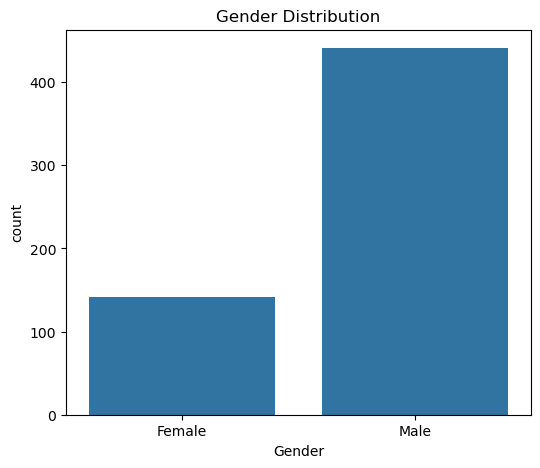

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(data=df , x = "Gender")

plt.title("Gender Distribution")

plt.show()

## - This graph shows the distribution of male and female patients.

### 5.3 Age Distribution

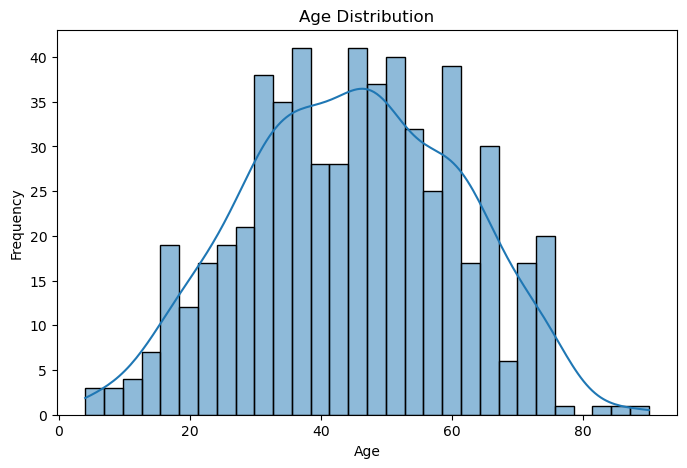

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x= "Age", bins= 30, kde= True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### 
- The histogram shows the distribution of patients based on age.
- It helps identify the most common age group affected by liver disease.
- It also indicates whether the age data is normally distributed or skewed.

### 5.4 Distribution of Numerical Features

In [17]:
numerical_columns = df.select_dtypes(include= ["int64","float64"]).columns

numerical_columns

Index(['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
       'Alamine_Aminotransferase', 'Aspartate_Aminotransferase',
       'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

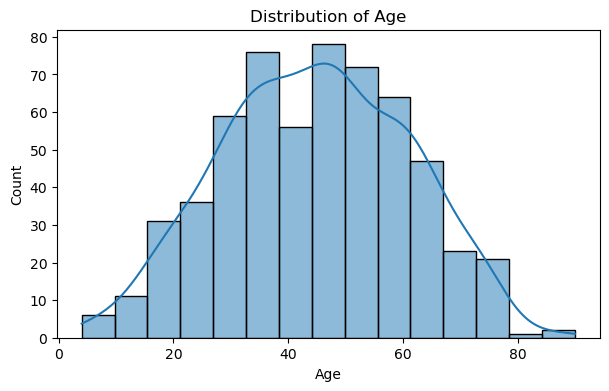

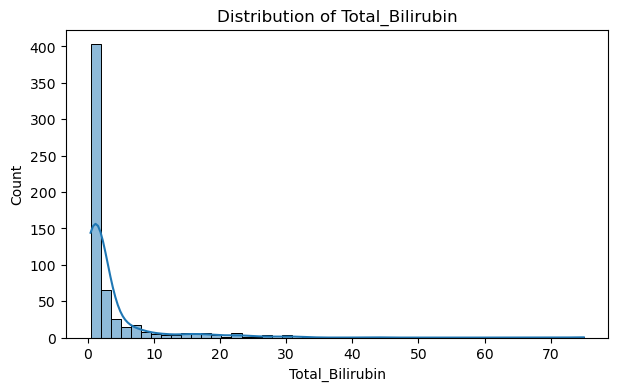

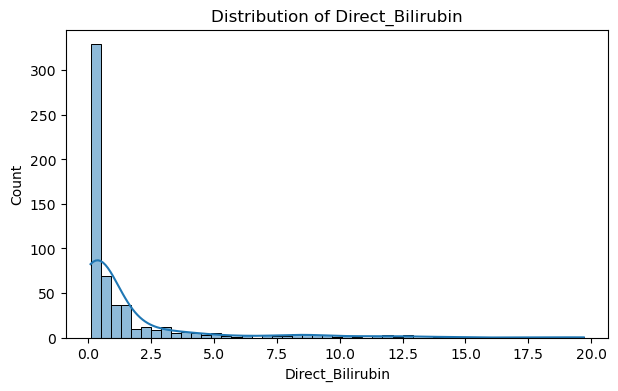

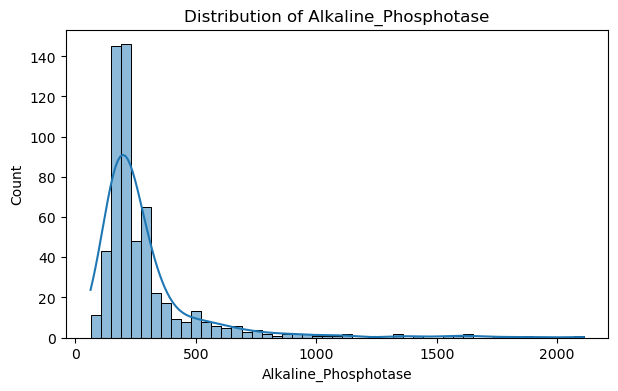

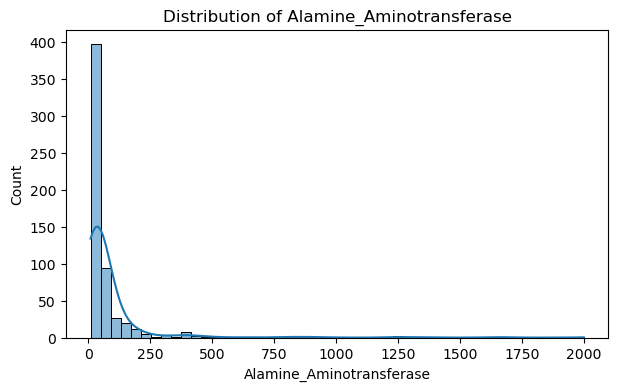

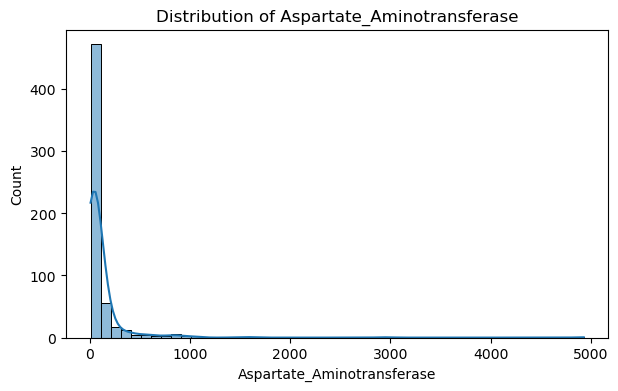

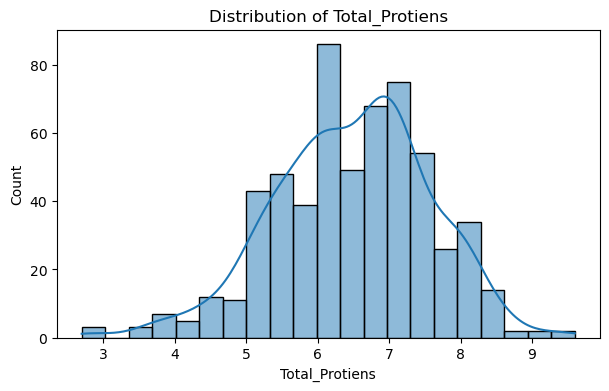

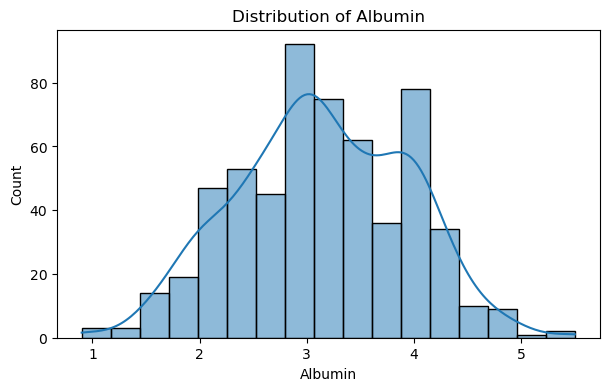

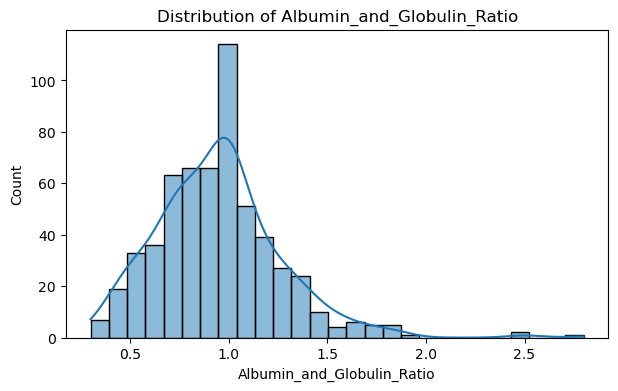

In [18]:
for column in numerical_columns[:-1]: 
    plt.figure(figsize=(7,4))

    sns.histplot(df[column],kde= True)

    plt.title(f"Distribution of {column}")

    plt.show()


- The above plots show the distribution of all numerical features.
- Some variables may be normally distributed, while others are positively skewed.
- These insights help in deciding whether feature transformation is required before model training.

## 5.5 Distribution of Categorical Features

In [19]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Gender'], dtype='object')

- The categorical feature shows the frequency of each category.
- This helps understand the distribution of categorical varia

# Step 6 : Outlier Analysis

## 6.1 Box Plot of Numerical Features

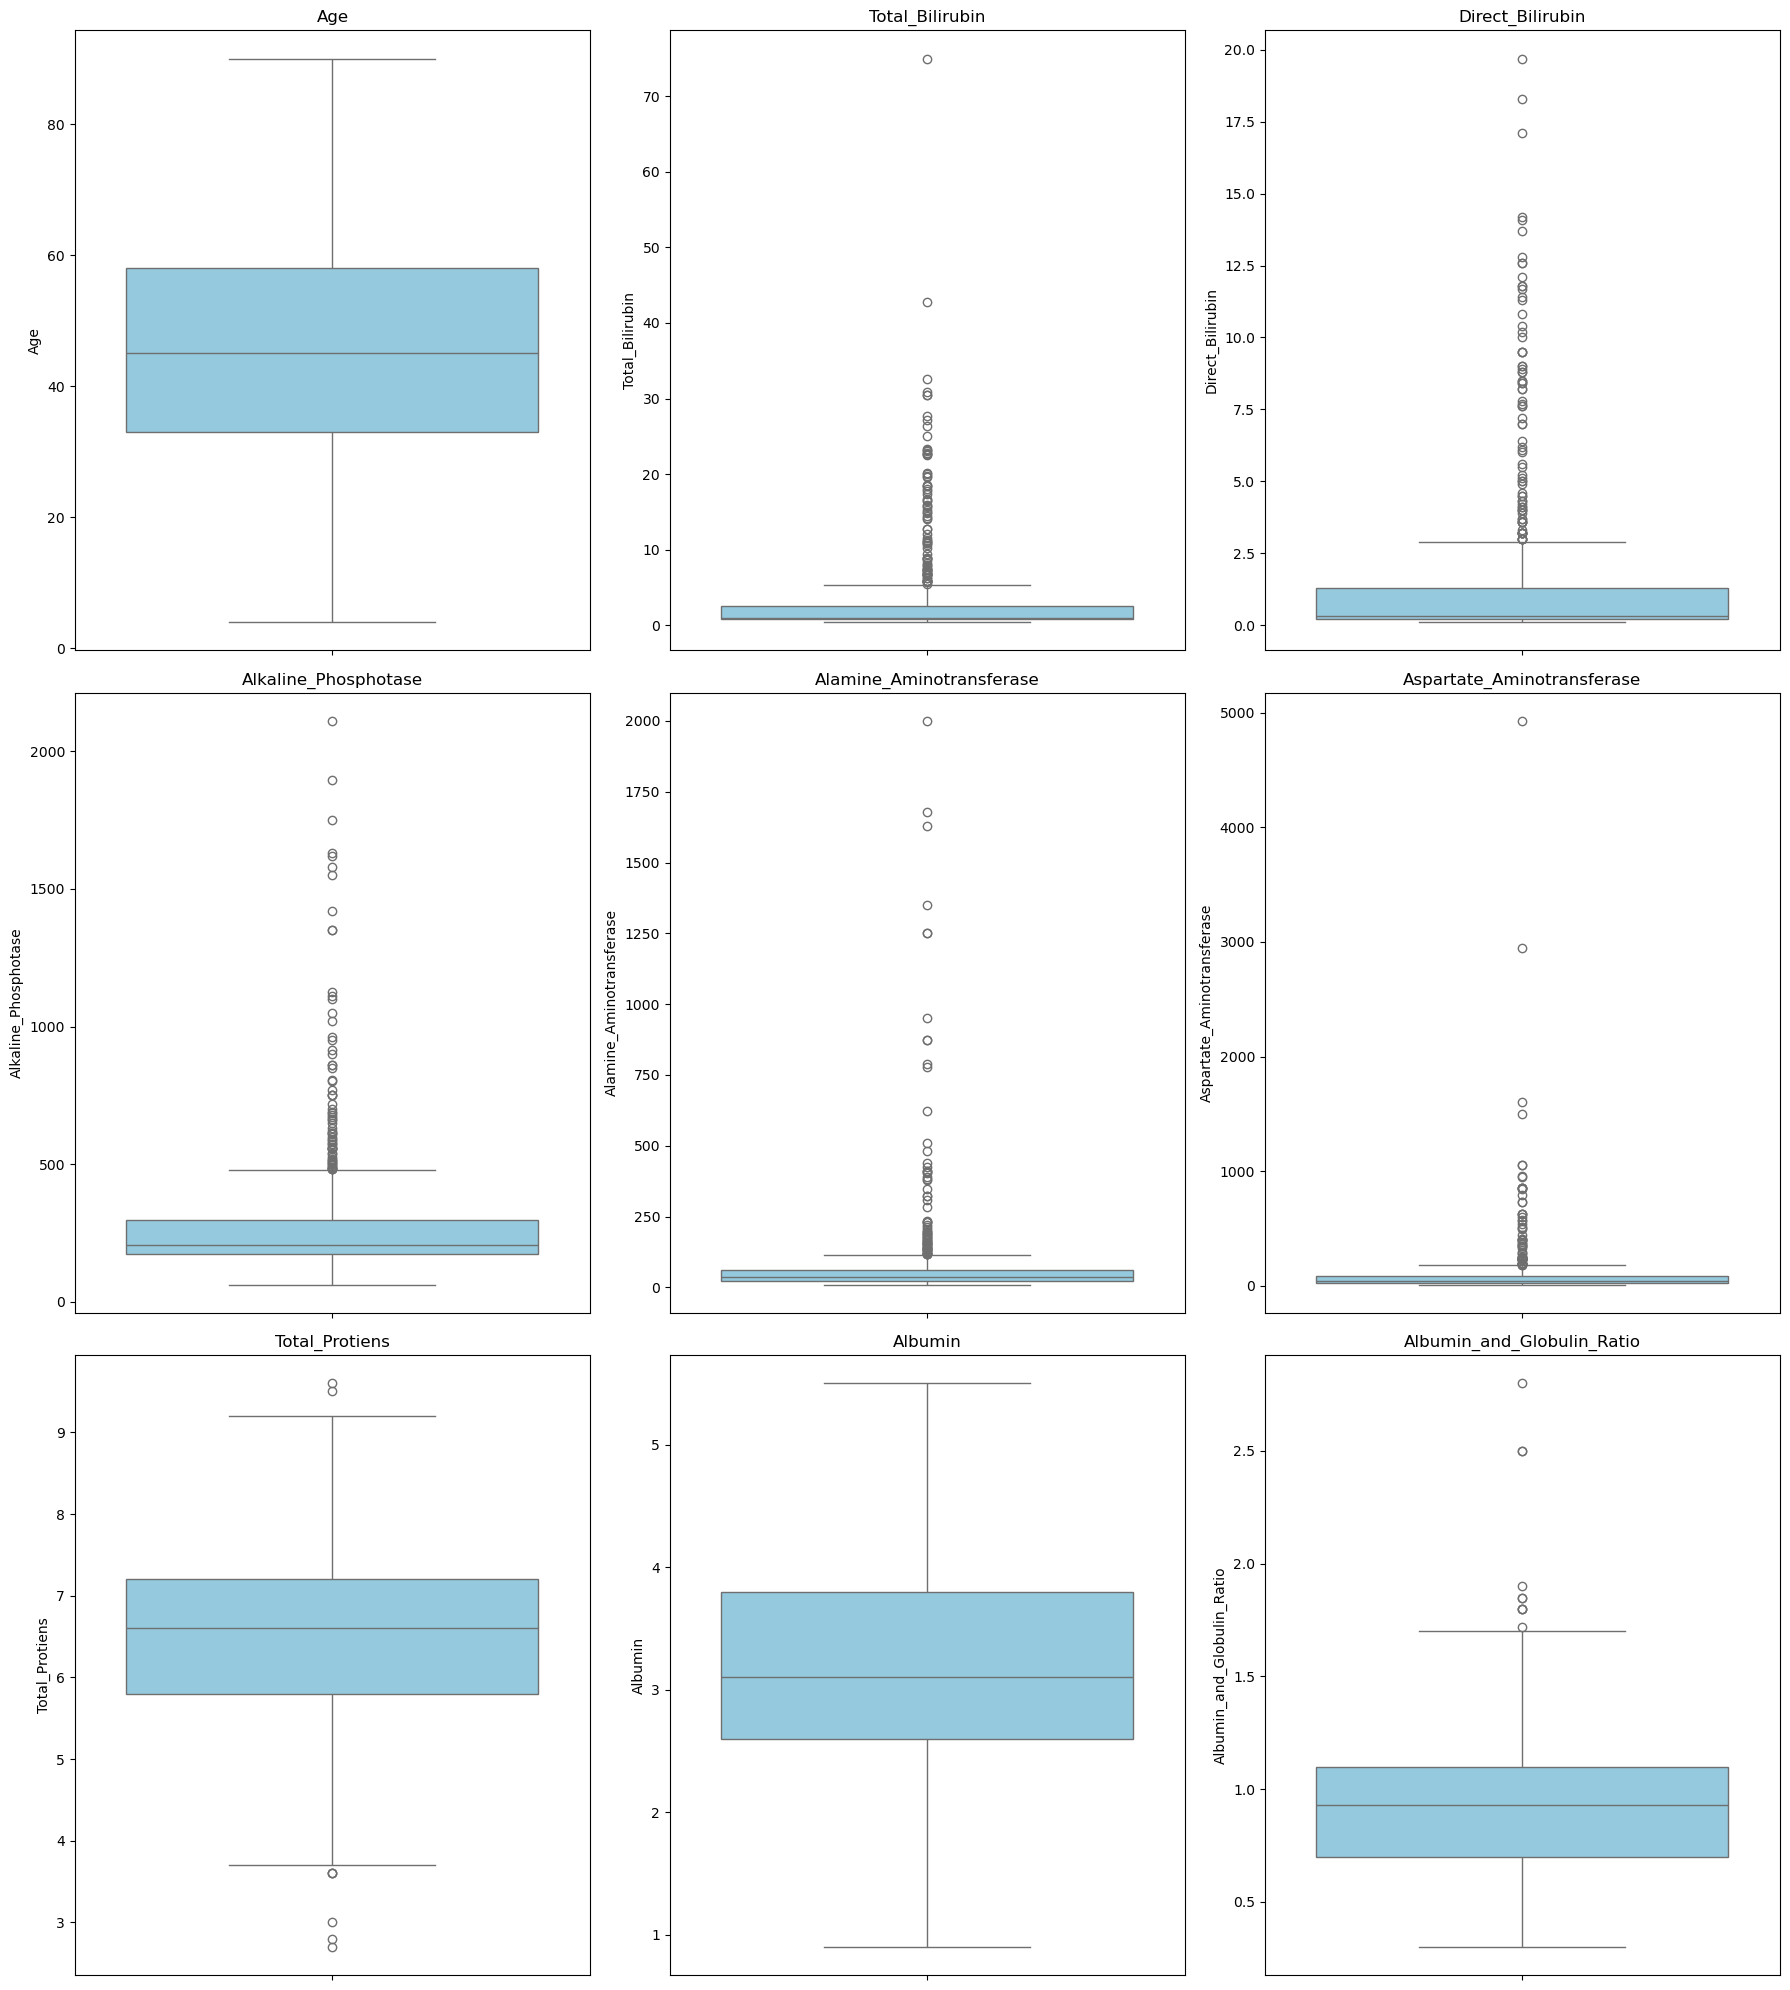

In [20]:
numerical_columns = [
    'Age',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphotase',
    'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase',
    'Total_Protiens',
    'Albumin',
    'Albumin_and_Globulin_Ratio'
]

plt.figure(figsize=(18,20))

for i, column in enumerate(numerical_columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[column],color='skyblue')
    plt.title(column)

plt.tight_layout()
plt.show()


- Boxplots are used to detect outliers in numerical features.
- Most biochemical parameters contain extreme values.
- Since this is a healthcare dataset, these values may represent actual patients rather than errors.
- Therefore, outliers will be analyzed carefully before deciding whether to remove them.

### Observation
 The Age feature contains very few outliers.
- Total Bilirubin and Direct Bilirubin contain a significant number of outliers.
- Alkaline Phosphotase, Alamine Aminotransferase, and Aspartate Aminotransferase have many extreme values.
- Total Proteins and Albumin have only a few outliers.
- Albumin and Globulin Ratio contains some outliers.
- Since this is a healthcare dataset, these extreme values may represent actual patient conditions rather than data errors. Therefore, outliers will not be removed without proper analysis.

In [21]:
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column} : {len(outliers)} Outliers")

Age : 0 Outliers
Total_Bilirubin : 84 Outliers
Direct_Bilirubin : 81 Outliers
Alkaline_Phosphotase : 69 Outliers
Alamine_Aminotransferase : 73 Outliers
Aspartate_Aminotransferase : 66 Outliers
Total_Protiens : 8 Outliers
Albumin : 0 Outliers
Albumin_and_Globulin_Ratio : 10 Outliers


## 
- The IQR method estimates the number of potential outliers in each feature.
- Outliers are common in medical datasets and should not be removed without proper analysis.

# Step 7 : Correlation Analysis

## 7.1 Correlation Heatmap

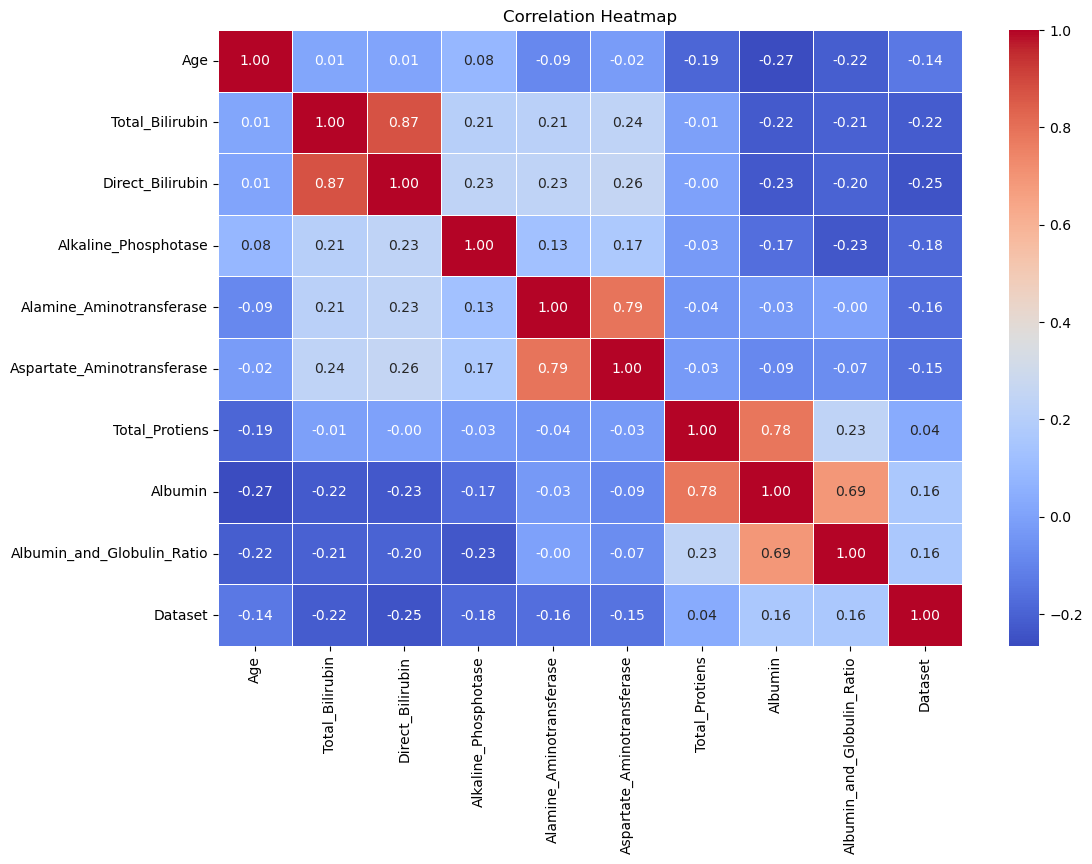

In [22]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot= True,
    cmap="coolwarm",
    fmt=".2f",
    linewidth=0.5
)

plt.title("Correlation Heatmap")

plt.show()


1. Total Bilirubin and Direct Bilirubin show a very strong positive correlation (0.87).

2. Alamine Aminotransferase and Aspartate Aminotransferase also have a strong positive correlation (0.79).

3. Total Proteins and Albumin are highly correlated (0.78).

4. Albumin and Albumin & Globulin Ratio have a moderate positive correlation (0.69).

5. Most other features show weak correlation with each other.

6. No pair of features has a perfect correlation (1.0), indicating that multicollinearity is not severe.

## 7.2 Correlation with Target Variable

In [23]:
correlation['Dataset'].sort_values(ascending=False)

Dataset                       1.000000
Albumin_and_Globulin_Ratio    0.163131
Albumin                       0.161388
Total_Protiens                0.035008
Age                          -0.137351
Aspartate_Aminotransferase   -0.151934
Alamine_Aminotransferase     -0.163416
Alkaline_Phosphotase         -0.184866
Total_Bilirubin              -0.220208
Direct_Bilirubin             -0.246046
Name: Dataset, dtype: float64

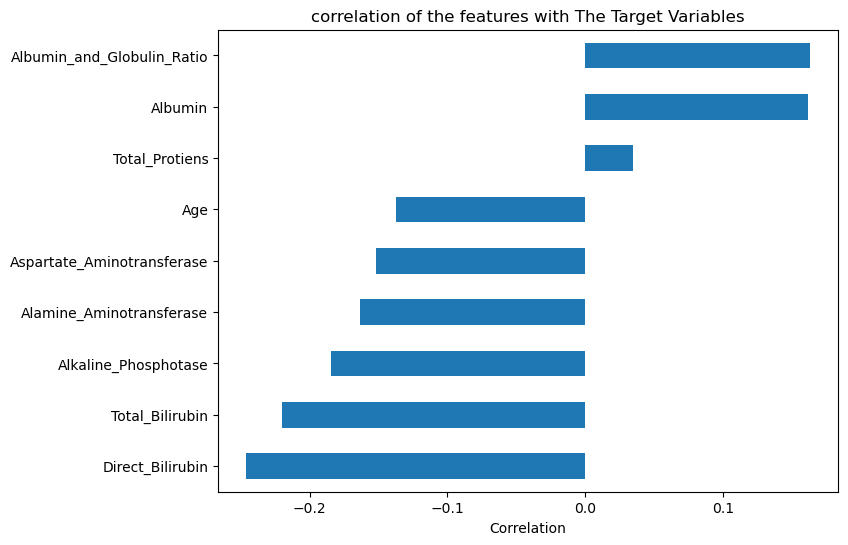

In [24]:
plt.figure(figsize=(8,6))

correlation["Dataset"].drop("Dataset").sort_values().plot(kind="barh")

plt.title("correlation of the features with The Target Variables")

plt.xlabel("Correlation")

plt.show()

1. Direct Bilirubin has the strongest negative correlation with the target variable.

2. Total Bilirubin also shows a relatively high negative correlation.

3. Albumin and Albumin & Globulin Ratio show positive correlation with the target.

4. Total Proteins has very weak correlation with the target.

5. Correlation values alone are not sufficient to determine feature importance, but they provide useful insights before model building.

# Step 8 : Bivariate Analysis

### 8.1 Age vs Liver Disease

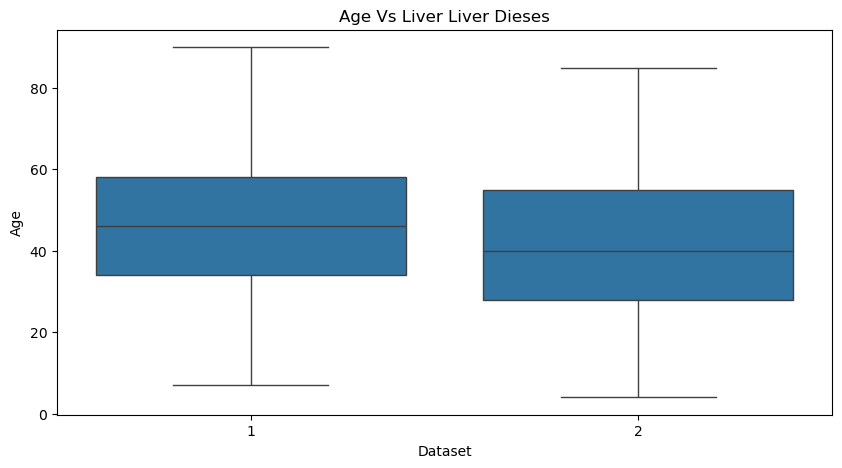

In [25]:
plt.figure(figsize=(10,5))

sns.boxplot( x= "Dataset", y = "Age" , data=df)

plt.title("Age Vs Liver Liver Dieses")

plt.show()

### - This plot compares the age distribution of liver disease and non-liver disease patients.
- It helps identify whether age influences liver disease.

### 8.2 Gender vs Liver Disease

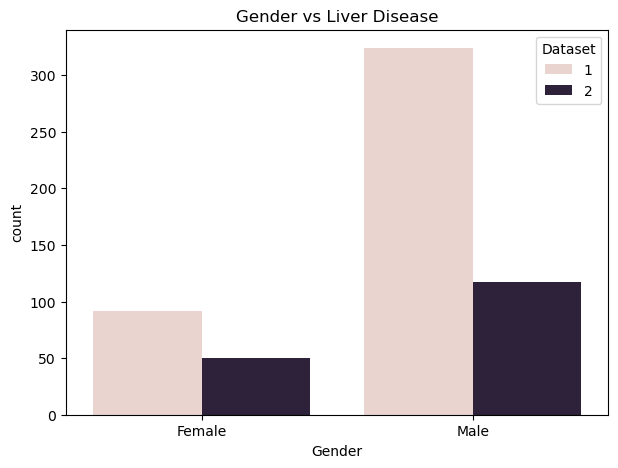

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(data=df , x="Gender" , hue = "Dataset")

plt.title("Gender vs Liver Disease")

plt.show()

- This graph compares liver disease cases between males and females.
- It helps identify whether liver disease is more common in a particular gender.
- in Both Dataset the male Hase More Liver Disease then Female

##  8.3 Total Bilirubin vs Liver Disease

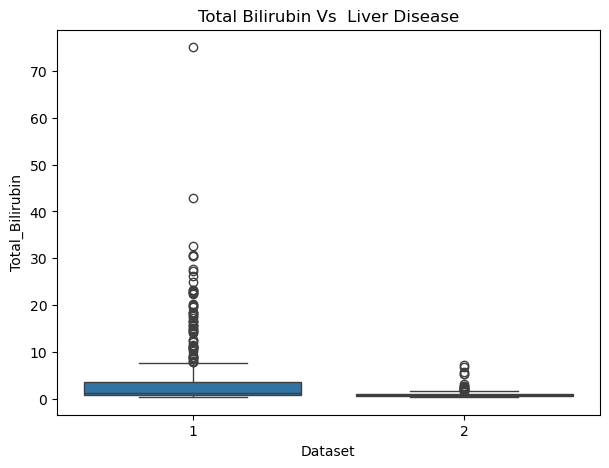

In [27]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Dataset", y = "Total_Bilirubin",data=df)

plt.title("Total Bilirubin Vs  Liver Disease")

plt.show()


- Patients with liver disease generally show higher Total Bilirubin values.
- Bilirubin is an important indicator of liver function.

## 8.4 Albumin vs Liver Disease

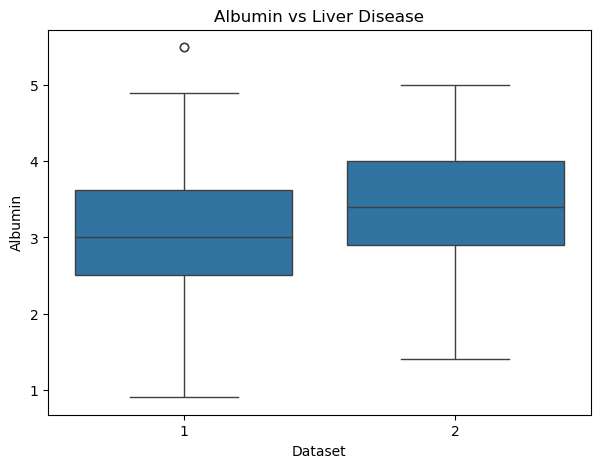

In [28]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Dataset", y="Albumin",data = df)

plt.title("Albumin vs Liver Disease")

plt.show()

- Albumin levels differ between liver disease and non-liver disease patients.
- Lower Albumin levels may indicate poor liver function.

## 8.5 Albumin & Globulin Ratio vs Liver Disease

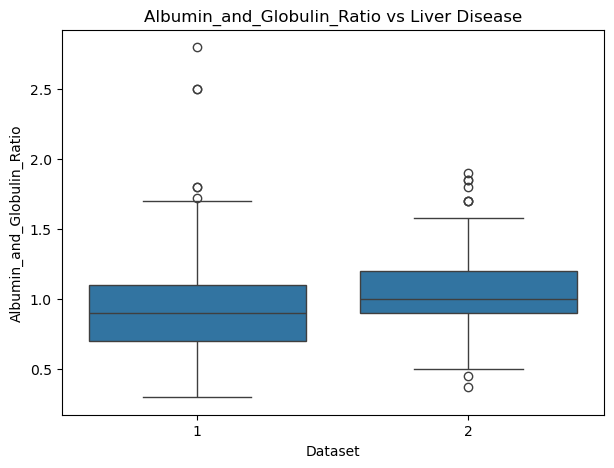

In [29]:
plt.figure(figsize=(7,5))

sns.boxplot(x= "Dataset", y="Albumin_and_Globulin_Ratio",data=df)

plt.title("Albumin_and_Globulin_Ratio vs Liver Disease")

plt.show()


- Albumin & Globulin Ratio varies between the two target classes.
- This feature may contribute significantly to prediction.

# Step 9 : Data Preprocessing

## 9.1 Handling Missing Values

In [30]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [31]:
df["Albumin_and_Globulin_Ratio"].fillna(
    df["Albumin_and_Globulin_Ratio"].median(), inplace=True
)

- The dataset contained only 4 missing values in the Albumin_and_Globulin_Ratio feature.
- Since the feature contains outliers, the median was used instead of the mean.
- After imputation, the dataset contains no missing values.

## 9.2 Encoding Categorical Features

In [32]:
df["Gender"].value_counts()

Gender
Male      441
Female    142
Name: count, dtype: int64

In [33]:
df["Gender"] = df["Gender"].map(
    {
        "Male" : 1,
        "Female": 0
    }
)

In [34]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1



- Gender is the only categorical feature in the dataset.
- Label Encoding was applied by mapping Male = 1 and Female = 0.

## 9.3 Feature Selection

In [35]:
X = df.drop("Dataset", axis= 1)

y = df["Dataset"]

In [36]:
print("Feature Shape:- ", X.shape)
print("Target Shape:- ",y.shape)

Feature Shape:-  (583, 10)
Target Shape:-  (583,)


- Independent variables are stored in X.
- Target variable is stored in y.
- The dataset contains 10 input features and 1 target variable.

# 9.4 Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split


In [38]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y
)

In [39]:
print("Training Feature: ", X_train.shape)
print("Testing Feature: ", X_test.shape)

print("Training Target:- ", y_train.shape)
print("Testing target:- ", y_test.shape)

Training Feature:  (466, 10)
Testing Feature:  (117, 10)
Training Target:-  (466,)
Testing target:-  (117,)


- The dataset was split into 80% training data and 20% testing data.
- Stratified sampling was used to preserve the class distribution in both sets.

In [40]:
from sklearn.preprocessing import StandardScaler


In [41]:
scaler = StandardScaler()
    
X_train_scaled= scaler.fit_transform(X_train)
    
X_test_scaled = scaler.transform(X_test)

- StandardScaler was applied to standardize the numerical features.
- The scaler was fitted only on the training data to avoid data leakage.
- The same transformation was then applied to the test data.

# step 10: Model Building

## 10.1 Import Machine Learning Libraries

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 10.2 Create Model Evaluation Function

In [43]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("=" * 60)
    print(f"Model : {model.__class__.__name__}")
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

    plt.title(model.__class__.__name__)

    plt.show()

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [44]:
Logistic_model = LogisticRegression(random_state=42)

Model : LogisticRegression
Accuracy  : 0.6923
Precision : 0.7282
Recall    : 0.9036
F1 Score  : 0.8065

Classification Report

              precision    recall  f1-score   support

           1       0.73      0.90      0.81        83
           2       0.43      0.18      0.25        34

    accuracy                           0.69       117
   macro avg       0.58      0.54      0.53       117
weighted avg       0.64      0.69      0.64       117



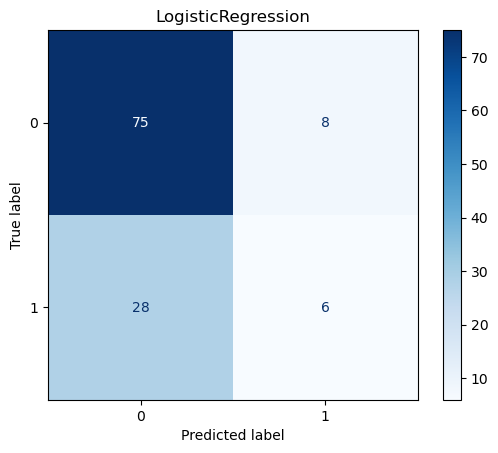

In [45]:
logistic_result = evaluate_model(
    Logistic_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

- Logistic Regression achieved an accuracy of 69.23%.
- The model has a high recall (90.36%), indicating that it successfully identifies most liver disease patients.
- The precision is moderate, meaning some healthy patients are incorrectly classified as having liver disease.
- Logistic Regression serves as a good baseline model for comparison with more advanced classifiers.

## 10.4 Model Performance Comparison

In [46]:
results = []

results.append(logistic_result)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452


## 10.5 Decision Tree Classifier

In [47]:
decision_tree  = DecisionTreeClassifier(
    random_state=42,
    max_depth= 5
)

Model : DecisionTreeClassifier
Accuracy  : 0.6410
Precision : 0.7030
Recall    : 0.8554
F1 Score  : 0.7717

Classification Report

              precision    recall  f1-score   support

           1       0.70      0.86      0.77        83
           2       0.25      0.12      0.16        34

    accuracy                           0.64       117
   macro avg       0.48      0.49      0.47       117
weighted avg       0.57      0.64      0.59       117



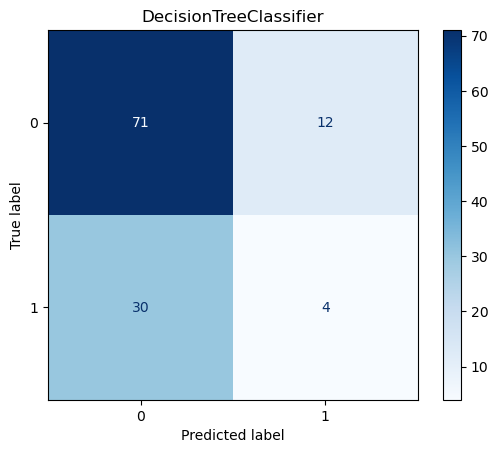

In [48]:
decision_tree_result = evaluate_model(
    decision_tree,
    X_train,X_test,y_train,y_test
)

In [49]:
results.append(decision_tree_result)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452
1,DecisionTreeClassifier,0.641026,0.702970,0.855422,0.771739



- Decision Tree captures non-linear relationships in the data.
- Limiting the tree depth helps reduce overfitting.
- The performance will be compared with Logistic Regression.

## 10.6 Random Forest Classifier

In [50]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

Model : RandomForestClassifier
Accuracy  : 0.6239
Precision : 0.7097
Recall    : 0.7952
F1 Score  : 0.7500

Classification Report

              precision    recall  f1-score   support

           1       0.71      0.80      0.75        83
           2       0.29      0.21      0.24        34

    accuracy                           0.62       117
   macro avg       0.50      0.50      0.50       117
weighted avg       0.59      0.62      0.60       117



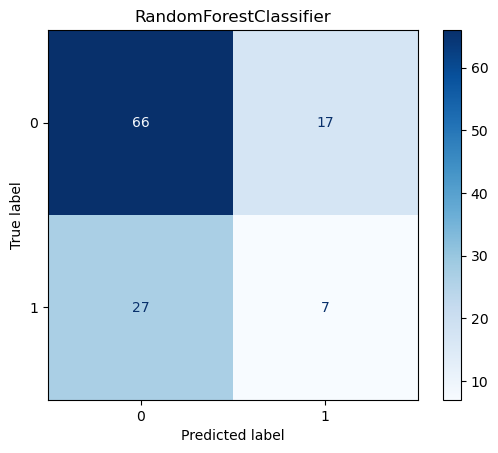

In [51]:
random_forest_result = evaluate_model(
    random_forest,
    X_train,X_test,y_train,y_test
)

In [52]:
results.append(random_forest_result)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452
1,DecisionTreeClassifier,0.641026,0.702970,0.855422,0.771739
2,RandomForestClassifier,0.623932,0.709677,0.795181,0.750000


## 10.7 K-Nearest Neighbors (KNN)

In [53]:
knn = KNeighborsClassifier(n_neighbors=5)

Model : KNeighborsClassifier
Accuracy  : 0.6410
Precision : 0.7470
Recall    : 0.7470
F1 Score  : 0.7470

Classification Report

              precision    recall  f1-score   support

           1       0.75      0.75      0.75        83
           2       0.38      0.38      0.38        34

    accuracy                           0.64       117
   macro avg       0.56      0.56      0.56       117
weighted avg       0.64      0.64      0.64       117



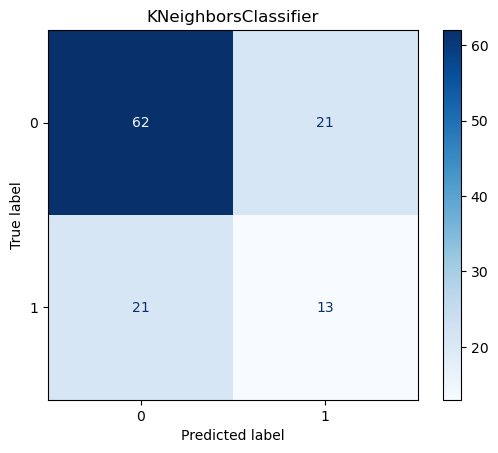

In [54]:
knn_result = evaluate_model(
    knn,
    X_train_scaled,X_test_scaled,y_train,y_test
)

In [55]:
results.append(knn_result)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452
1,DecisionTreeClassifier,0.641026,0.702970,0.855422,0.771739
2,KNeighborsClassifier,0.641026,0.746988,0.746988,0.746988
3,RandomForestClassifier,0.623932,0.709677,0.795181,0.750000



- KNN classifies samples based on the nearest neighboring data points.
- Feature scaling is essential for KNN because it relies on distance calculations.
- The model performance is compared with previously trained classifiers.

## 10.8 Gaussian Naive Bayes

In [56]:
naive_bayes = GaussianNB()

Model : GaussianNB
Accuracy  : 0.5385
Precision : 0.9394
Recall    : 0.3735
F1 Score  : 0.5345

Classification Report

              precision    recall  f1-score   support

           1       0.94      0.37      0.53        83
           2       0.38      0.94      0.54        34

    accuracy                           0.54       117
   macro avg       0.66      0.66      0.54       117
weighted avg       0.78      0.54      0.54       117



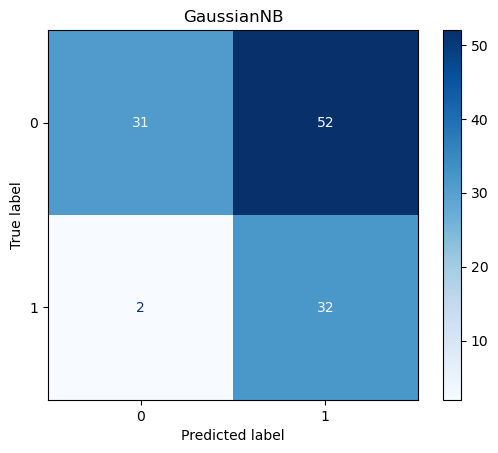

In [57]:
naive_bayes_result = evaluate_model(
    naive_bayes,
    X_train_scaled,X_test_scaled,y_train,y_test
)

In [58]:
results.append(naive_bayes_result)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452
1,DecisionTreeClassifier,0.641026,0.702970,0.855422,0.771739
2,KNeighborsClassifier,0.641026,0.746988,0.746988,0.746988
3,RandomForestClassifier,0.623932,0.709677,0.795181,0.750000
4,GaussianNB,0.538462,0.939394,0.373494,0.534483


## 10.9 Support Vector Machine (SVM)

In [59]:
svm = SVC(
    kernel= "rbf",
    random_state=42
)

Model : SVC
Accuracy  : 0.6838
Precision : 0.7018
Recall    : 0.9639
F1 Score  : 0.8122

Classification Report

              precision    recall  f1-score   support

           1       0.70      0.96      0.81        83
           2       0.00      0.00      0.00        34

    accuracy                           0.68       117
   macro avg       0.35      0.48      0.41       117
weighted avg       0.50      0.68      0.58       117



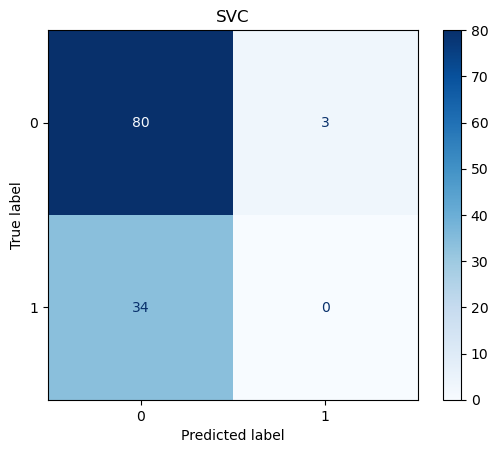

In [60]:
svm_result= evaluate_model(
    svm,
    X_train_scaled,X_test_scaled,y_train,y_test
)

In [61]:
results.append(svm_result)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452
1,SVC,0.683761,0.701754,0.963855,0.812183
2,DecisionTreeClassifier,0.641026,0.702970,0.855422,0.771739
3,KNeighborsClassifier,0.641026,0.746988,0.746988,0.746988
4,RandomForestClassifier,0.623932,0.709677,0.795181,0.750000
5,GaussianNB,0.538462,0.939394,0.373494,0.534483


In [62]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452
1,SVC,0.683761,0.701754,0.963855,0.812183
2,DecisionTreeClassifier,0.641026,0.702970,0.855422,0.771739
3,KNeighborsClassifier,0.641026,0.746988,0.746988,0.746988
4,RandomForestClassifier,0.623932,0.709677,0.795181,0.750000
5,GaussianNB,0.538462,0.939394,0.373494,0.534483


# Step 11 : Hyperparameter Tuning

## 11.1 Hyperparameter Tuning using GridSearchCV (Logistic Regression)

In [63]:
from sklearn.model_selection import GridSearchCV

In [64]:
# Create Logistic Regression model 

logistic = LogisticRegression(random_state=42)

# Para meters to check 

param_grid = {
    "C": [0.01,0.1,1,10,100],
    "solver": ["liblinear","lbfgs"],
    "max_iter": [100,200,500]
}

In [65]:
grid_search = GridSearchCV(
    estimator=logistic,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train_scaled,y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'max_iter': [100, 200, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [66]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 100, 'max_iter': 100, 'solver': 'liblinear'}


In [67]:
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.7209791809654542


In [68]:
best_logistic = grid_search.best_estimator_

Model : LogisticRegression
Accuracy  : 0.6838
Precision : 0.7347
Recall    : 0.8675
F1 Score  : 0.7956

Classification Report

              precision    recall  f1-score   support

           1       0.73      0.87      0.80        83
           2       0.42      0.24      0.30        34

    accuracy                           0.68       117
   macro avg       0.58      0.55      0.55       117
weighted avg       0.64      0.68      0.65       117



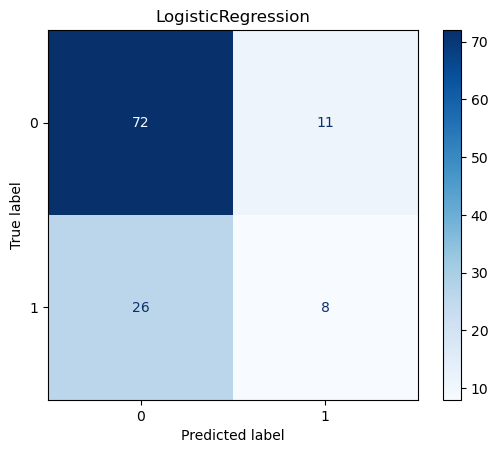

In [69]:
best_logistic_result = evaluate_model(
    best_logistic,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

# Step 12 : Feature Importance Analysis

## 12.1 Feature Importance using Random Forest

In [70]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by = "Importance",
    ascending = False
)

feature_importance

,Feature,Importance
4,Alkaline_Phosphotase,0.163732
5,Alamine_Aminotransferase,0.128635
0,Age,0.125462
6,Aspartate_Aminotransferase,0.122507
2,Total_Bilirubin,0.107073
3,Direct_Bilirubin,0.096797
8,Albumin,0.088487
7,Total_Protiens,0.081806
9,Albumin_and_Globulin_Ratio,0.075143
1,Gender,0.010356


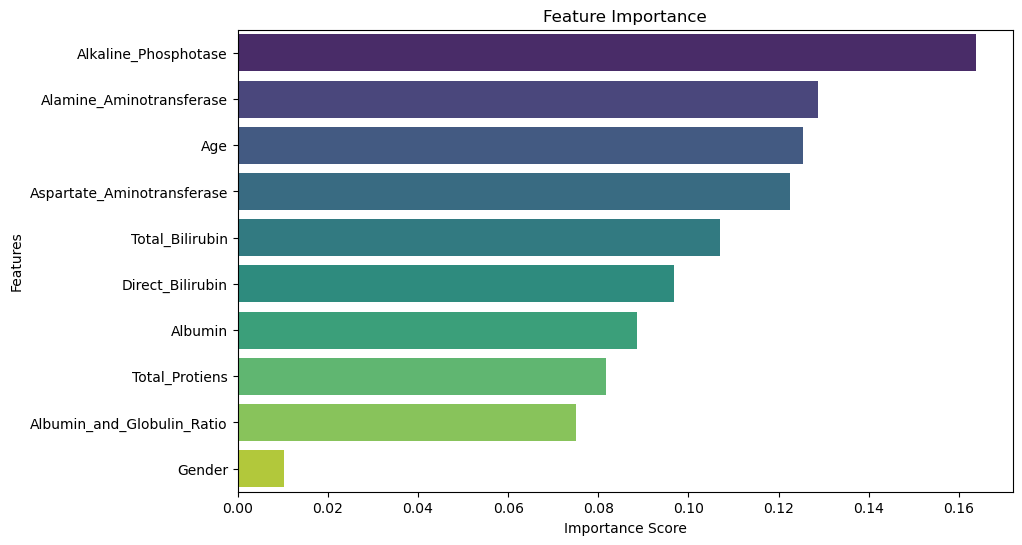

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

- Random Forest provides feature importance scores.
- Features with higher importance contribute more towards predicting liver disease.
- This analysis helps explain why the model makes predictions and supports feature selection.

# Step 13 : ROC Curve Analysis

In [72]:
from sklearn.metrics import roc_curve,roc_auc_score


In [73]:
df["Dataset"] = df["Dataset"].replace({1:0,2:1})

In [74]:
df["Dataset"].value_counts()

Dataset
0    416
1    167
Name: count, dtype: int64

## 13.1 Updated Model Evaluation Function

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [76]:
def evaluate_model(model,X_train,X_test,y_train,y_test):
    #Train
    model.fit(X_train,y_train)

    #Prediction
    y_pred = model.predict(X_test)

    # Probability
    if hasattr(model, "predict_proba"):
        y_prob = model.predict.proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

        # Metrics
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,ypred)
    roc_auc = roc_auc_score(y_test,y_prob)


    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print(f"Accuracy:-  {accuracy:.4f}")
    print(f"Precision:- {precision:.4f}")
    print(f"Recall :- {recall:.4f}")
    print(f"F1_score:- {f1:.4f}")
    print(f"roc_auc_Score:- {roc_auc:.4f}")

    cm = confusion_matrix(y_test,y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")

    plt.title(model.__class__.__name__)

    plt.show()

    return {
        "model" : model.__class__.__name__,
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1_Score" : f1,
        "Roc_AUC" : roc_auc
    }

## 13.2 Feature Importance

In [77]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Alkaline_Phosphotase,0.163732
5,Alamine_Aminotransferase,0.128635
0,Age,0.125462
6,Aspartate_Aminotransferase,0.122507
2,Total_Bilirubin,0.107073
3,Direct_Bilirubin,0.096797
8,Albumin,0.088487
7,Total_Protiens,0.081806
9,Albumin_and_Globulin_Ratio,0.075143
1,Gender,0.010356


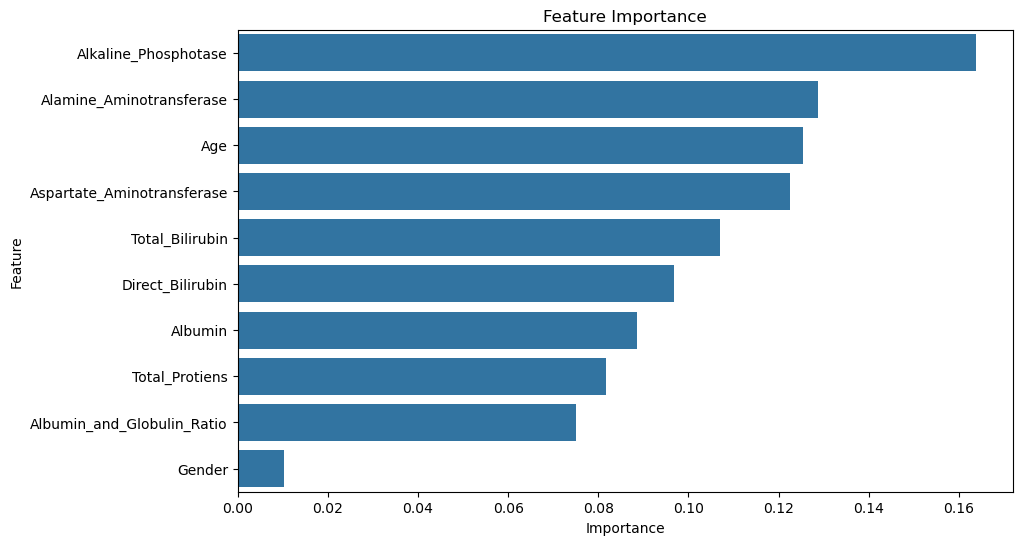

In [78]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# Step 14 : Model Comparison Report

In [79]:
results_df = pd.DataFrame(results)

results_df = results_df.drop_duplicates(subset="Model")

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.692308,0.728155,0.903614,0.806452
1,SVC,0.683761,0.701754,0.963855,0.812183
2,DecisionTreeClassifier,0.641026,0.702970,0.855422,0.771739
3,KNeighborsClassifier,0.641026,0.746988,0.746988,0.746988
4,RandomForestClassifier,0.623932,0.709677,0.795181,0.750000
5,GaussianNB,0.538462,0.939394,0.373494,0.534483


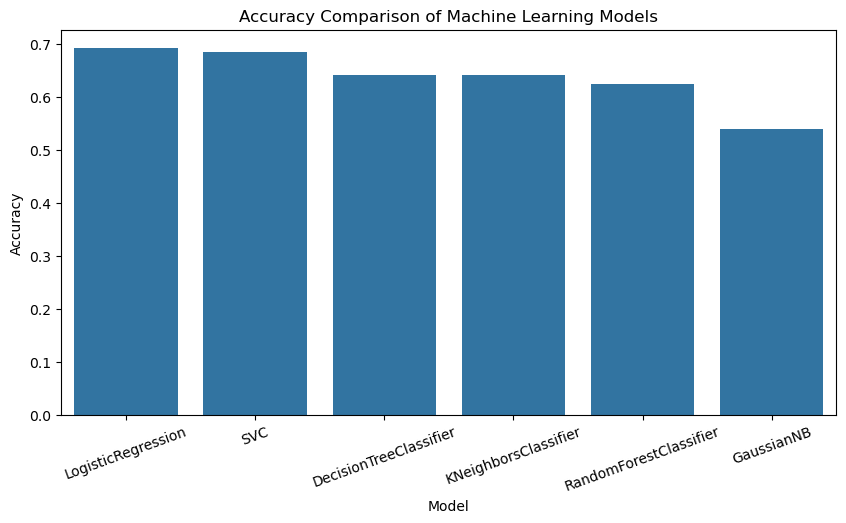

In [80]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xticks(rotation=20)

plt.show()


- Logistic Regression achieved the highest accuracy among all evaluated models.
- SVM achieved a comparable performance with a high F1-score.
- Decision Tree, Random Forest, and KNN showed moderate performance.
- Gaussian Naive Bayes achieved the lowest performance on this dataset.

# Step 15 : Best Model Selection

In [81]:
best_model = results_df.iloc[0]

best_model

Model        LogisticRegression
Accuracy               0.692308
Precision              0.728155
Recall                 0.903614
F1 Score               0.806452
Name: 0, dtype: object

### Conclusion

Among all the implemented machine learning models, Logistic Regression achieved the highest accuracy on the testing dataset.

Therefore, Logistic Regression is selected as the final production model for this project.

Reasons:

- Highest Accuracy
- High Recall
- High F1 Score
- Simple and Fast
- Less Computational Cost
- Suitable for Healthcare Classification Problems

# Step 16 : Challenges Faced

### Challenges Faced During the Project

1. The dataset contained missing values in the Albumin_and_Globulin_Ratio feature.

2. The dataset contained several outliers because it is a healthcare dataset.

3. The target classes were slightly imbalanced.

4. Selecting the most suitable machine learning model required comparing multiple classifiers.

5. Hyperparameter tuning did not significantly improve Logistic Regression performance, indicating that the baseline model was already well-suited for this dataset.

# Step 17 : Final Conclusion

### Final Conclusion

This project focused on predicting liver disease using the Indian Liver Patient Dataset (ILPD).

Initially, the dataset was explored through detailed Exploratory Data Analysis (EDA), followed by preprocessing techniques such as handling missing values, encoding categorical variables, feature scaling, and train-test splitting.

Multiple machine learning algorithms including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Gaussian Naive Bayes, and Support Vector Machine were implemented and evaluated.

Among all the models, Logistic Regression achieved the best overall performance on the test dataset.

Feature importance analysis revealed that biochemical parameters such as Alkaline Phosphotase, Alamine Aminotransferase, Total Bilirubin, Direct Bilirubin, and Age contributed significantly to liver disease prediction.

The developed predictive model can assist healthcare professionals in identifying liver disease patients more efficiently and may serve as a decision-support system for early diagnosis.

# Step 18 : Model Explainability using SHAP

## 18.1 Install SHAP (Run only if not already installed)

In [82]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [83]:
import shap


In [84]:
explainer = shap.TreeExplainer(random_forest)

In [85]:
shap_values = explainer.shap_values(X_test)

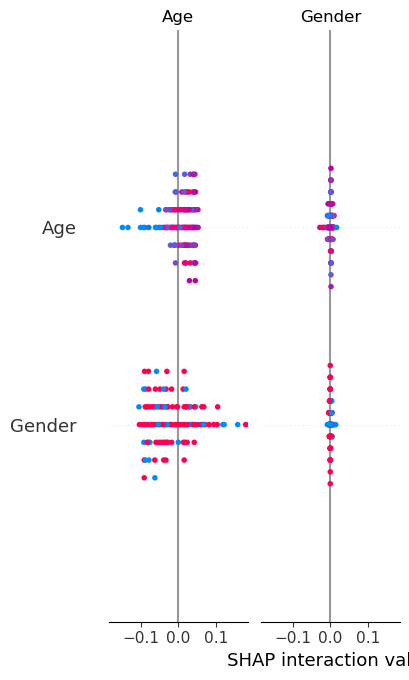

In [86]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

### Observation

The SHAP Summary Plot provides the overall contribution of each feature towards the model predictions.

Features appearing at the top of the plot contribute the most to liver disease prediction.

In [87]:
shap.initjs()

In [88]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X.columns
    )
)

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (10, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [ ]:
print(type(shap_values))

In [ ]:
try:
    print(len(shap_values))
except:
    print("No Length")

In [ ]:
print(shap.__version__)

In [ ]:
shap_values = explainer.shap_values(X_test)

In [ ]:
explainer = shap.Explainer(random_forest)

shap_values = explainer(X_test)

In [ ]:
print(shap.__version__)

In [ ]:
print(type(shap_values))

In [ ]:
print(shap_values.shape)

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
shap.plots.waterfall(shap_values[0, :, 1])

In [ ]:
shap.plots.bar(shap_values[:, :, 1])

# Step 18 : Save the Final Model

In [92]:
import pickle

In [93]:
best_model = Logistic_model

In [94]:
with open("liver_disease_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model Saved Successfully ✅")

Model Saved Successfully ✅
